In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, Input
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

In [ ]:
drive.mount('/content/drive')
file_path = '/content/drive/MyDrive/Colab Notebooks/RobotArm_ANN/FixedReach_Workspace_Data.xlsx'
df = pd.read_excel(file_path)

output_cols = ['Q1', 'Q2', 'Q3', 'Q4', 'Q5']
df[output_cols] = np.degrees(df[output_cols])

df['R_dist'] = np.sqrt(df['X']**2 + df['Y']**2 + df['Z']**2)
df['r_xy'] = np.sqrt(df['X']**2 + df['Y']**2)

angle_features = ['Roll', 'Pitch', 'Yaw']
for col in angle_features:
    df[f'sin_{col}'] = np.sin(np.radians(df[col]))
    df[f'cos_{col}'] = np.cos(np.radians(df[col]))

feature_cols = ['X', 'Y', 'Z', 'R_dist', 'r_xy',
                'sin_Roll', 'cos_Roll',
                'sin_Pitch', 'cos_Pitch',
                'sin_Yaw', 'cos_Yaw']

kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(df[output_cols])

main_cluster_id = df['Cluster'].value_counts().idxmax()
df_train = df[df['Cluster'] == main_cluster_id].copy()

X = df_train[feature_cols].values
y = df_train[output_cols].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=42)

scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_train_scaled = scaler_X.fit_transform(X_train)
y_train_scaled = scaler_y.fit_transform(y_train)
X_test_scaled = scaler_X.transform(X_test)
y_test_scaled = scaler_y.transform(y_test)

Mounted at /content/drive


In [ ]:
def build_model(input_dim, output_dim):
    model = Sequential([
        Input(shape=(input_dim,)),
        Dense(1024, activation='relu'),
        BatchNormalization(),
        Dropout(0.05),

        Dense(1024, activation='relu'),
        BatchNormalization(),

        Dense(512, activation='relu'),
        BatchNormalization(),

        Dense(256, activation='relu'),

        Dense(output_dim, activation='linear')
    ])
    return model

model = build_model(X_train_scaled.shape[1], y_train_scaled.shape[1])

optimizer = Adam(learning_rate=0.0005)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, min_lr=1e-7)
early_stop = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)

model.compile(loss='mean_squared_error', optimizer=optimizer, metrics=['mae'])

history = model.fit(
    X_train_scaled, y_train_scaled,
    validation_data=(X_test_scaled, y_test_scaled),
    epochs=150,
    batch_size=32,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

Epoch 1/150
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 44s 28ms/step - loss: 0.3206 - mae: 0.4135 - val_loss: 0.1024 - val_mae: 0.2343 - learning_rate: 5.0000e-04
Epoch 2/150
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 71s 48ms/step - loss: 0.1092 - mae: 0.2442 - val_loss: 0.0662 - val_mae: 0.1839 - learning_rate: 5.0000e-04
Epoch 3/150
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 51s 27ms/step - loss: 0.0840 - mae: 0.2101 - val_loss: 0.0572 - val_mae: 0.1655 - learning_rate: 5.0000e-04
Epoch 4/150
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 39s 26ms/step - loss: 0.0728 - mae: 0.1919 - val_loss: 0.0496 - val_mae: 0.1473 - learning_rate: 5.0000e-04
Epoch 5/150
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 38s 25ms/step - loss: 0.0620 - mae: 0.1755 - val_loss: 0.0443 - val_mae: 0.1390 - learning_rate: 5.0000e-04
Epoch 6/150
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 39s 26ms/step - loss: 0.0559 - mae: 0.1648 - val_loss: 0.0438 - val_mae: 0.1356 - learning_rate: 5.0000e-04
Epoch 7/150
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 42s 28ms/step - loss: 0.0530 - mae: 0.1581 - val_lo

167/167 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
Joint      | MAE (deg)       | Accuracy (<1°)
---------------------------------------------
Q1         | 1.7750          | 38.08%
Q2         | 2.2837          | 36.80%
Q3         | 3.5113          | 32.62%
Q4         | 1.0592          | 58.62%
Q5         | 2.6609          | 33.45%
---------------------------------------------
Overall Accuracy: 39.91%


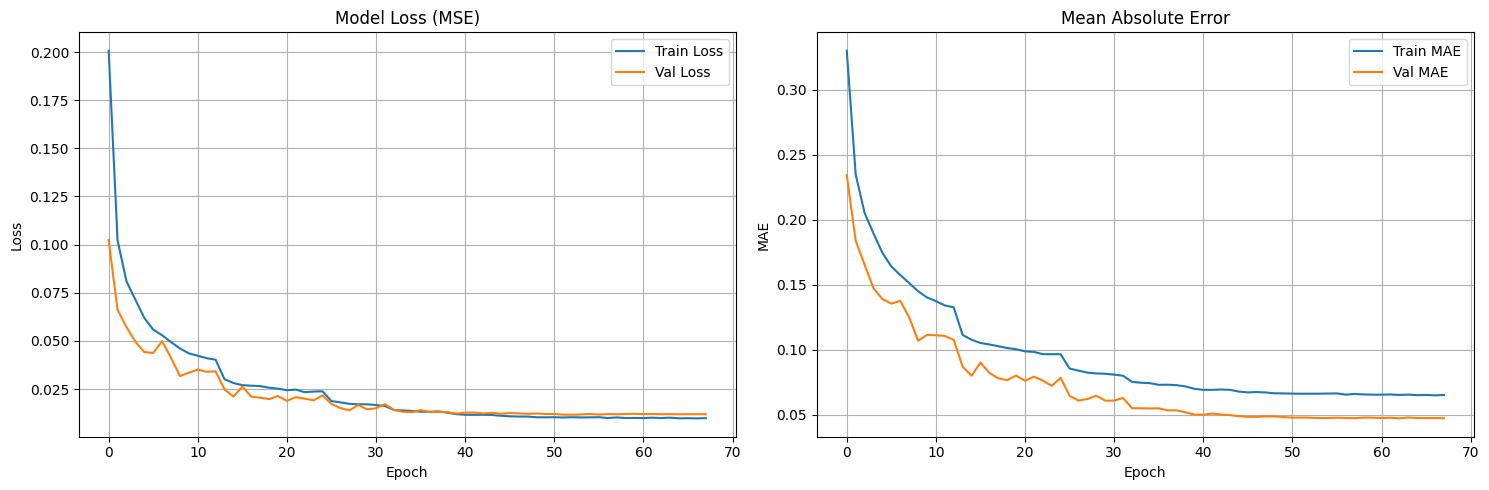

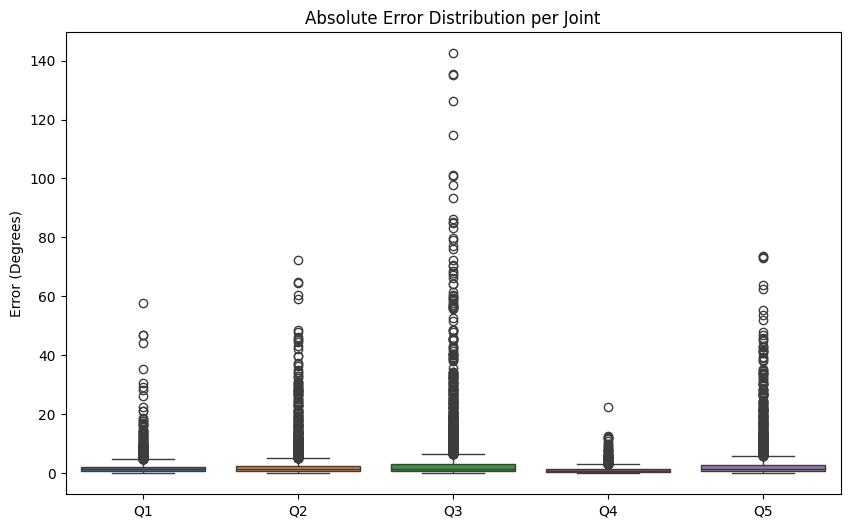

In [ ]:
predictions_scaled = model.predict(X_test_scaled)
predictions_degrees = scaler_y.inverse_transform(predictions_scaled)
y_test_degrees = scaler_y.inverse_transform(y_test_scaled)

abs_errors = np.abs(predictions_degrees - y_test_degrees)
mae_per_joint = np.mean(abs_errors, axis=0)
acc_per_joint = np.mean(abs_errors < 1.0, axis=0) * 100

print(f"{'Joint':<10} | {'MAE (deg)':<15} | {'Accuracy (<1°)'}")
print("-" * 45)
for i, joint in enumerate(output_cols):
    print(f"{joint:<10} | {mae_per_joint[i]:.4f}          | {acc_per_joint[i]:.2f}%")
print("-" * 45)
print(f"Overall Accuracy: {np.mean(abs_errors < 1.0) * 100:.2f}%")

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].plot(history.history['loss'], label='Train Loss')
axes[0].plot(history.history['val_loss'], label='Val Loss')
axes[0].set_title('Model Loss (MSE)')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(history.history['mae'], label='Train MAE')
axes[1].plot(history.history['val_mae'], label='Val MAE')
axes[1].set_title('Mean Absolute Error')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('MAE')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
sns.boxplot(data=pd.DataFrame(abs_errors, columns=output_cols))
plt.title('Absolute Error Distribution per Joint')
plt.ylabel('Error (Degrees)')
plt.show()

In [ ]:
def predict_robot_joints(x, y, z, roll, pitch, yaw):
    r_dist = np.sqrt(x**2 + y**2 + z**2)
    r_xy = np.sqrt(x**2 + y**2)

    rad_r, rad_p, rad_y = np.radians([roll, pitch, yaw])

    features = np.array([[
        x, y, z, r_dist, r_xy,
        np.sin(rad_r), np.cos(rad_r),
        np.sin(rad_p), np.cos(rad_p),
        np.sin(rad_y), np.cos(rad_y)
    ]])

    features_scaled = scaler_X.transform(features)
    pred_scaled = model.predict(features_scaled, verbose=0)
    return scaler_y.inverse_transform(pred_scaled)[0]

test_target = {'x': 37, 'y': 29, 'z': 418, 'roll': -34, 'pitch': -7, 'yaw': 40}
predicted_angles = predict_robot_joints(**test_target)

print(f"\nTarget: {test_target}")
print("Predicted Joints (Degrees):")
for label, angle in zip(output_cols, predicted_angles):
    print(f"{label}: {angle:.2f}")

model.save('/content/drive/MyDrive/Robot_Model_FeatureEngineered_Professional.keras')


Target: {'x': 37, 'y': 29, 'z': 418, 'roll': -34, 'pitch': -7, 'yaw': 40}
Predicted Joints (Degrees):
Q1: 40.51
Q2: -13.46
Q3: 11.03
Q4: -55.28
Q5: 83.92


In [ ]:

save_path = '/content/drive/MyDrive/High_Precision_Robot_Model.keras'
model.save(save_path)

import joblib

joblib.dump(scaler_X, '/content/drive/MyDrive/scaler_X.pkl')

joblib.dump(scaler_y, '/content/drive/MyDrive/scaler_y.pkl')


['/content/drive/MyDrive/scaler_y.pkl']